In [ ]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#create the dataframes from csv files
student_life_df = pd.read_csv('../Data/AI_Impact_Student_Life_2026.csv')
jobs_df = pd.read_csv('../Data/ai_job_impact.csv')
content_df = pd.read_csv('../Data/Global_AI_Content_Impact_Dataset.csv')

In [ ]:
#function created to perform an introductory check with any dataframes put into the argument
def intro_report(list_of_df):
    for df in list_of_df:
        print("Overview of Dataframes")
        print("\nFirst 5 Rows:")
        print(df.head())
        print("\nLast 5 Rows:")
        print(df.tail())
        print('\nNulls and Data Types:')
        print(df.info())
        print('\nRows by Columns')
        print (df.shape)

intro_report([student_life_df, content_df, jobs_df])

Overview of Dataframes

First 5 Rows:
  Student_ID  Age                 Major Primary_AI_Tool  Task_Frequency_Daily  \
0   STU-6019   23  Software Engineering      Gemini Pro                     1   
1   STU-6962   22        Modern History  GitHub Copilot                     3   
2   STU-2338   18          Data Science      Perplexity                     2   
3   STU-1380   19               Biology      Claude 3.5                     5   
4   STU-1837   19               Biology      ChatGPT-4o                    10   

     Main_Usage_Case  GPA_Baseline  GPA_Post_AI  Time_Saved_Hours_Weekly  \
0     Code Debugging          2.62         2.62                        9   
1     Essay Drafting          3.99         4.00                        7   
2  Literature Review          2.57         2.57                       15   
3     Essay Drafting          2.67         2.87                       12   
4     Code Debugging          3.65         3.85                        5   

  AI_Ethics_Concer

In [ ]:
#ensure that all three dataframes follow a singular naming convention
def standardize(list_of_df):
    for df in list_of_df:
        df.columns = df.columns.str.lower().str.replace(" ", "_")

standardize([student_life_df, content_df, jobs_df])

In [ ]:
#compare gpa before and after ai
student_life_df[['gpa_baseline', 'gpa_post_ai']]

,gpa_baseline,gpa_post_ai
0,2.62,2.62
1,3.99,4.00
2,2.57,2.57
3,2.67,2.87
4,3.65,3.85
...,...,...
1495,3.35,3.55
1496,3.59,3.89
1497,3.20,3.40
1498,3.99,4.00


In [ ]:
#boolean indexing to filter with conditions to find the students whose gpas grew, then using .shape to look at the number of students in this category
gpa_growth_df = student_life_df[student_life_df['gpa_baseline'] < student_life_df['gpa_post_ai']]
gpa_growth_df.shape

(894, 11)

In [ ]:
#the number of students whose gpas decreased
gpa_decline_df = student_life_df[student_life_df['gpa_baseline'] > student_life_df['gpa_post_ai']]
gpa_decline_df.shape

(301, 11)

In [ ]:
#the number of students whos gpas stayed the same
gpa_same_df = student_life_df[student_life_df['gpa_baseline'] == student_life_df['gpa_post_ai']]
gpa_same_df.shape

(305, 11)

In [ ]:
#overview of the integer and float datatypes in this dataframe
student_life_df.describe()

,age,task_frequency_daily,gpa_baseline,gpa_post_ai,time_saved_hours_weekly,career_confidence_score
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000
mean,21.494000,5.407333,3.256853,3.344587,8.51000,5.417333
std,2.297277,2.905462,0.430583,0.437409,4.07148,2.844977
min,18.000000,1.000000,2.500000,2.400000,2.00000,1.000000
25%,20.000000,3.000000,2.880000,2.980000,5.00000,3.000000
50%,21.000000,5.000000,3.260000,3.360000,9.00000,5.000000
75%,23.000000,8.000000,3.620000,3.710000,12.00000,8.000000
max,25.000000,10.000000,4.000000,4.000000,15.00000,10.000000


In [ ]:
#which ai tool was used the most with students
student_life_df['primary_ai_tool'].value_counts()

primary_ai_tool
GitHub Copilot    311
Gemini Pro        302
Perplexity        302
Claude 3.5        297
ChatGPT-4o        288
Name: count, dtype: int64

In [ ]:
#which ai tool was used the most with people at work
content_df['top_ai_tools_used'].value_counts()

top_ai_tools_used
Midjourney          37
Claude              31
ChatGPT             31
Stable Diffusion    27
DALL-E              26
Bard                24
Synthesia           24
Name: count, dtype: int64

In [818]:
jobs_df.describe()

,age,years_experience,salary_before_ai,salary_after_ai,work_hours_per_week,job_satisfaction,productivity_change_%
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,40.558000,16.663500,73942.072500,78428.642500,44.85100,6.020500,9.785820
std,10.786418,10.746675,26055.823793,29351.599013,5.71254,2.006263,17.187882
min,22.000000,0.000000,30036.000000,24447.000000,35.00000,3.000000,-19.990000
25%,32.000000,8.000000,51665.500000,54086.750000,40.00000,4.000000,-5.355000
50%,40.000000,16.000000,74620.000000,76820.500000,45.00000,6.000000,9.850000
75%,50.000000,26.000000,95418.250000,100730.250000,50.00000,8.000000,24.582500
max,59.000000,37.000000,119976.000000,161745.000000,54.00000,9.000000,39.990000


In [ ]:
#summarize the years of experience into three categories and create a new column with these values
def categorize_experience(years_experience):
    if years_experience <= 2:
        return 'Entry Level'
    elif years_experience >= 3 and years_experience < 5:
        return 'Mid Level'
    else:
        return 'Senior'

jobs_df['experience_level'] = jobs_df['years_experience'].apply(categorize_experience)
jobs_df

,employee_id,age,gender,education_level,industry,job_role,years_experience,ai_adoption_level,automation_risk,upskilling_required,salary_before_ai,salary_after_ai,job_status,work_hours_per_week,remote_work,job_satisfaction,productivity_change_%,experience_level
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64,Senior
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05,Senior
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05,Senior
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47,Senior
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03,Entry Level
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,E1996,55,Other,PhD,Healthcare,Technician,30,Medium,Low,Yes,99082,101090,Unchanged,52,Yes,7,25.67,Senior
1996,E1997,31,Male,PhD,Finance,Investment Analyst,9,High,Medium,Yes,32379,44653,Modified,52,Yes,8,9.38,Senior
1997,E1998,43,Female,Bachelor,Retail,Cashier,17,High,High,No,53424,74715,Modified,49,Yes,6,-0.57,Senior
1998,E1999,43,Female,Bachelor,Marketing,Digital Marketer,20,Medium,Low,No,57821,68499,Unchanged,41,No,9,9.31,Senior


In [ ]:
#create a similar variable to adoption level in jobs_df from adoption rate in content_df for future queries in SQL
def categorize_adoption_rate(adoption_rate):
    if adoption_rate <= 33.33:
        return 'Low'
    elif adoption_rate >= 33.34 and adoption_rate <= 66.66:
        return 'Medium'
    else:
        return 'High'

content_df['ai_adoption_level'] = content_df['ai_adoption_rate_(%)'].apply(categorize_adoption_rate)
content_df


,country,year,industry,ai_adoption_rate_(%),ai-generated_content_volume_(tbs_per_year),job_loss_due_to_ai_(%),revenue_increase_due_to_ai_(%),human-ai_collaboration_rate_(%),top_ai_tools_used,regulation_status,consumer_trust_in_ai_(%),market_share_of_ai_companies_(%),ai_adoption_level
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73,Medium
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02,Medium
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76,High
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93,High
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35,High
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73,High
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62,Medium
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11,Medium


In [ ]:
#standardize the names of ai tools to use them both together later in queries
student_life_df['primary_ai_tool'] = student_life_df['primary_ai_tool'].replace({'Claude 3.5': 'Claude', 'ChatGPT-4o': 'ChatGPT'})
student_life_df['primary_ai_tool'].value_counts()

primary_ai_tool
GitHub Copilot    311
Gemini Pro        302
Perplexity        302
Claude            297
ChatGPT           288
Name: count, dtype: int64

In [ ]:
#check for null values
student_life_df.isnull()

,student_id,age,major,primary_ai_tool,task_frequency_daily,main_usage_case,gpa_baseline,gpa_post_ai,time_saved_hours_weekly,ai_ethics_concern,career_confidence_score
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1495,False,False,False,False,False,False,False,False,False,False,False
1496,False,False,False,False,False,False,False,False,False,False,False
1497,False,False,False,False,False,False,False,False,False,False,False
1498,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
#show the number of nulls, if any
student_life_df.isnull().sum()

student_id                 0
age                        0
major                      0
primary_ai_tool            0
task_frequency_daily       0
main_usage_case            0
gpa_baseline               0
gpa_post_ai                0
time_saved_hours_weekly    0
ai_ethics_concern          0
career_confidence_score    0
dtype: int64

In [ ]:
#display datatypes
jobs_df.dtypes

employee_id                  str
age                        int64
education_level              str
industry                     str
job_role                     str
years_experience           int64
ai_adoption_level            str
automation_risk              str
upskilling_required          str
salary_before_ai           int64
salary_after_ai            int64
job_status                   str
work_hours_per_week        int64
remote_work                  str
job_satisfaction           int64
productivity_change_%    float64
experience_level             str
dtype: object

In [ ]:
#check for any duplicate rows
duplicate_sum = student_life_df.duplicated().sum()

print(duplicate_sum)

0


In [ ]:
#rename the column to match the other datasets ai tools column
content_df.rename(columns={'top_ai_tools_used': 'ai_tool'}, inplace=True)
content_df

,country,year,industry,ai_adoption_rate_(%),ai-generated_content_volume_(tbs_per_year),job_loss_due_to_ai_(%),revenue_increase_due_to_ai_(%),human-ai_collaboration_rate_(%),ai_tool,regulation_status,consumer_trust_in_ai_(%),market_share_of_ai_companies_(%),ai_adoption_level
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73,Medium
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02,Medium
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76,High
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93,High
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35,High
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73,High
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62,Medium
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11,Medium


In [ ]:
#renaming the other column to match
student_life_df.rename(columns={'primary_ai_tool': 'ai_tool'}, inplace=True)
student_life_df


,student_id,age,major,ai_tool,task_frequency_daily,main_usage_case,gpa_baseline,gpa_post_ai,time_saved_hours_weekly,ai_ethics_concern,career_confidence_score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT,10,Code Debugging,3.65,3.85,5,High,9
...,...,...,...,...,...,...,...,...,...,...,...
1495,STU-2711,21,Modern History,GitHub Copilot,4,Brainstorming,3.35,3.55,7,Medium,7
1496,STU-4888,21,Biology,GitHub Copilot,3,Essay Drafting,3.59,3.89,13,Medium,7
1497,STU-0180,23,Software Engineering,GitHub Copilot,8,Code Debugging,3.20,3.40,7,Low,2
1498,STU-4392,23,Fine Arts,Perplexity,6,Brainstorming,3.99,4.00,15,Low,7


I used the dataframes I made before to see which Primary AI Tool had the worst/best post-AI GPA on average.

In [ ]:
#which ai tool is associated with a higher gpa on average
gpa_growth_df.groupby(student_life_df['ai_tool'])['gpa_post_ai'].mean()

ai_tool
ChatGPT           3.439773
Claude            3.458671
Gemini Pro        3.486872
GitHub Copilot    3.426902
Perplexity        3.433352
Name: gpa_post_ai, dtype: float64

In [ ]:
#which ai tool is associated with a lower gpa on average
gpa_decline_df.groupby(student_life_df['ai_tool'])['gpa_post_ai'].mean()

ai_tool
ChatGPT           3.217647
Claude            3.042069
Gemini Pro        3.193913
GitHub Copilot    3.109219
Perplexity        3.161017
Name: gpa_post_ai, dtype: float64

In [ ]:
#overview of the gpa post ai based on usage case within each major
round(gpa_growth_df.groupby(['major', 'main_usage_case'])['gpa_post_ai'].mean(), 2)

major                    main_usage_case  
Biology                  Brainstorming        3.58
                         Code Debugging       3.51
                         Essay Drafting       3.54
                         Exam Prep            3.50
                         Literature Review    3.36
Business Administration  Brainstorming        3.37
                         Code Debugging       3.47
                         Essay Drafting       3.44
                         Exam Prep            3.45
                         Literature Review    3.43
Data Science             Brainstorming        3.52
                         Code Debugging       3.42
                         Essay Drafting       3.36
                         Exam Prep            3.51
                         Literature Review    3.38
Fine Arts                Brainstorming        3.36
                         Code Debugging       3.45
                         Essay Drafting       3.39
                         Exam Prep     

In [ ]:
#a look at the changes in productivity by industry
jobs_df.groupby('industry')['productivity_change_%'].agg(['min', 'mean', 'max'])

,min,mean,max
industry,,,
Education,-19.99,10.014505,39.83
Finance,-19.58,9.565767,39.90
Healthcare,-19.88,9.307259,39.82
IT,-19.91,9.061074,39.99
Manufacturing,-19.93,10.697390,39.97
Marketing,-19.77,10.332527,39.91
Retail,-19.92,9.512878,39.86


In [ ]:
#check how much time was saved on average and how many tasks were done with ai daily for each tool and use case
student_life_df.groupby([student_life_df['ai_tool'], 'main_usage_case']).agg({
    'time_saved_hours_weekly': 'mean',
    'task_frequency_daily': 'count'

})

time_saved_hours_weekly  \
ai_tool        main_usage_case                              
ChatGPT        Brainstorming                     8.038462   
               Code Debugging                    7.897959   
               Essay Drafting                    8.666667   
               Exam Prep                         8.376812   
               Literature Review                 8.545455   
Claude         Brainstorming                     8.826923   
               Code Debugging                    8.604167   
               Essay Drafting                    8.490909   
               Exam Prep                         7.970588   
               Literature Review                 7.810811   
Gemini Pro     Brainstorming                     8.553846   
               Code Debugging                    8.920000   
               Essay Drafting                    9.211538   
               Exam Prep                         8.586207   
               Literature Review                 7.958333   
GitHub Copilot Brainstorming                     8.126984   
               Code Debugging                    7.406780   
               Essay Drafting                    8.677966   
               Exam Prep                         8.813559   
               Literature Review                 9.070423   
Perplexity     Brainstorming                     9.648148   
               Code Debugging                    8.706897   
               Essay Drafting                    8.791667   
               Exam Prep                         8.500000   
               Literature Review                 8.666667   

                                  task_frequency_daily  
ai_tool        main_usage_case                          
ChatGPT        Brainstorming                        52  
               Code Debugging                       49  
               Essay Drafting                       63  
               Exam Prep                            69  
               Literature Review                    55  
Claude         Brainstorming                        52  
               Code Debugging                       48  
               Essay Drafting                       55  
               Exam Prep                            68  
               Literature Review                    74  
Gemini Pro     Brainstorming                        65  
               Code Debugging                       50  
               Essay Drafting                       52  
               Exam Prep                            87  
               Literature Review                    48  
GitHub Copilot Brainstorming                        63  
               Code Debugging                       59  
               Essay Drafting                       59  
               Exam Prep                            59  
               Literature Review                    71  
Perplexity     Brainstorming                        54  
               Code Debugging                       58  
               Essay Drafting                       72  
               Exam Prep                            58  
               Literature Review                    60

In [ ]:
#create a list from merging these three columns from different datasets
def create_list(unique_dfs):
    return pd.concat(unique_dfs).unique()
domain_list = create_list([student_life_df['major'], jobs_df['industry'], content_df['industry']])
domain_list


<StringArray>
[   'Software Engineering',          'Modern History',
            'Data Science',                 'Biology',
 'Business Administration',               'Fine Arts',
               'Marketing',           'Manufacturing',
                      'IT',               'Education',
              'Healthcare',                 'Finance',
                  'Retail',                   'Media',
                   'Legal',              'Automotive',
                  'Gaming']
Length: 17, dtype: str

In [ ]:
#create a dataframe from a column made from the list
def makedf(col_name, list_name):
    return pd.DataFrame({col_name: list(list_name)})

domains_df = makedf('domain_name', domain_list)
domains_df

,domain_name
0,Software Engineering
1,Modern History
2,Data Science
3,Biology
4,Business Administration
5,Fine Arts
6,Marketing
7,Manufacturing
8,IT
9,Education


In [ ]:
#create the surrogate key
def add_id(df_name, col_name):
    df_name[col_name] = range(1, len(df_name) + 1)
    return df_name
add_id(domains_df, 'domain_id')



,domain_name,domain_id
0,Software Engineering,1
1,Modern History,2
2,Data Science,3
3,Biology,4
4,Business Administration,5
5,Fine Arts,6
6,Marketing,7
7,Manufacturing,8
8,IT,9
9,Education,10


In [ ]:
#create the list from the ai tools in student life and content
ai_tools_list = create_list([student_life_df['ai_tool'], content_df['ai_tool']])

In [ ]:
#create the dataframe from that list
ai_tools_df = makedf('ai_tool', ai_tools_list)



In [ ]:
#create the surrogate key
add_id(ai_tools_df, 'ai_tool_id')

,ai_tool,ai_tool_id
0,Gemini Pro,1
1,GitHub Copilot,2
2,Perplexity,3
3,Claude,4
4,ChatGPT,5
5,Bard,6
6,DALL-E,7
7,Stable Diffusion,8
8,Midjourney,9
9,Synthesia,10


In [ ]:
#create a dictionary map
domains_map = dict(zip(domains_df['domain_name'], domains_df['domain_id']))
#create a function for mapping foreign keys to dataframes before being made into tables
def fkmapping(df_name, col_name, col_name2, map_name):
    df_name[col_name] = df_name[col_name2].map(map_name)
    return df_name

#map the foreign key domain_id to student life matching on the majors 
fkmapping(student_life_df, 'domain_id', 'major', domains_map)

,student_id,age,major,ai_tool,task_frequency_daily,main_usage_case,gpa_baseline,gpa_post_ai,time_saved_hours_weekly,ai_ethics_concern,career_confidence_score,domain_id
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3,1
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4,2
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7,3
3,STU-1380,19,Biology,Claude,5,Essay Drafting,2.67,2.87,12,Low,5,4
4,STU-1837,19,Biology,ChatGPT,10,Code Debugging,3.65,3.85,5,High,9,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,STU-2711,21,Modern History,GitHub Copilot,4,Brainstorming,3.35,3.55,7,Medium,7,2
1496,STU-4888,21,Biology,GitHub Copilot,3,Essay Drafting,3.59,3.89,13,Medium,7,4
1497,STU-0180,23,Software Engineering,GitHub Copilot,8,Code Debugging,3.20,3.40,7,Low,2,1
1498,STU-4392,23,Fine Arts,Perplexity,6,Brainstorming,3.99,4.00,15,Low,7,6


In [ ]:
#map domain_id as a foreign key to jobs matching on industry
fkmapping(jobs_df, 'domain_id', 'industry', domains_map)

,employee_id,age,education_level,industry,job_role,years_experience,ai_adoption_level,automation_risk,upskilling_required,salary_before_ai,salary_after_ai,job_status,work_hours_per_week,remote_work,job_satisfaction,productivity_change_%,experience_level,domain_id
0,E0001,50,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64,Senior,7
1,E0002,45,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05,Senior,8
2,E0003,51,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05,Senior,9
3,E0004,48,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47,Senior,10
4,E0005,24,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03,Entry Level,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,E1996,55,PhD,Healthcare,Technician,30,Medium,Low,Yes,99082,101090,Unchanged,52,Yes,7,25.67,Senior,11
1996,E1997,31,PhD,Finance,Investment Analyst,9,High,Medium,Yes,32379,44653,Modified,52,Yes,8,9.38,Senior,12
1997,E1998,43,Bachelor,Retail,Cashier,17,High,High,No,53424,74715,Modified,49,Yes,6,-0.57,Senior,13
1998,E1999,43,Bachelor,Marketing,Digital Marketer,20,Medium,Low,No,57821,68499,Unchanged,41,No,9,9.31,Senior,7


In [ ]:
#do the same for content
fkmapping(content_df, 'domain_id', 'industry', domains_map)

,country,year,industry,ai_adoption_rate_(%),ai-generated_content_volume_(tbs_per_year),job_loss_due_to_ai_(%),revenue_increase_due_to_ai_(%),human-ai_collaboration_rate_(%),ai_tool,regulation_status,consumer_trust_in_ai_(%),market_share_of_ai_companies_(%),ai_adoption_level,domain_id
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73,Medium,14
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02,Medium,15
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76,High,16
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93,High,15
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41,High,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35,High,16
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73,High,14
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62,Medium,7
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11,Medium,16


In [ ]:
#create the dictionary map for the ai tool id column
ai_tools_map = dict(zip(ai_tools_df['ai_tool'], ai_tools_df['ai_tool_id']))
#map the id to students matching on ai tool
fkmapping(student_life_df, 'ai_tool_id', 'ai_tool', ai_tools_map)

,student_id,age,major,ai_tool,task_frequency_daily,main_usage_case,gpa_baseline,gpa_post_ai,time_saved_hours_weekly,ai_ethics_concern,career_confidence_score,domain_id,ai_tool_id
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3,1,1
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4,2,2
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7,3,3
3,STU-1380,19,Biology,Claude,5,Essay Drafting,2.67,2.87,12,Low,5,4,4
4,STU-1837,19,Biology,ChatGPT,10,Code Debugging,3.65,3.85,5,High,9,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,STU-2711,21,Modern History,GitHub Copilot,4,Brainstorming,3.35,3.55,7,Medium,7,2,2
1496,STU-4888,21,Biology,GitHub Copilot,3,Essay Drafting,3.59,3.89,13,Medium,7,4,2
1497,STU-0180,23,Software Engineering,GitHub Copilot,8,Code Debugging,3.20,3.40,7,Low,2,1,2
1498,STU-4392,23,Fine Arts,Perplexity,6,Brainstorming,3.99,4.00,15,Low,7,6,3


In [ ]:
#do the same for content
fkmapping(content_df, 'ai_tool_id', 'ai_tool', ai_tools_map)

,country,year,industry,ai_adoption_rate_(%),ai-generated_content_volume_(tbs_per_year),job_loss_due_to_ai_(%),revenue_increase_due_to_ai_(%),human-ai_collaboration_rate_(%),ai_tool,regulation_status,consumer_trust_in_ai_(%),market_share_of_ai_companies_(%),ai_adoption_level,domain_id,ai_tool_id
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73,Medium,14,6
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02,Medium,15,7
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76,High,16,8
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93,High,15,4
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41,High,17,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35,High,16,7
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73,High,14,7
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62,Medium,7,10
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11,Medium,16,4


In [ ]:
#creating averages of these values to put into the domains table
avg_satisfaction = jobs_df.groupby('domain_id')['job_satisfaction'].mean()
avg_loss = content_df.groupby('domain_id')['job_loss_due_to_ai_(%)'].mean()
avg_trust = content_df.groupby('domain_id')['consumer_trust_in_ai_(%)'].mean()

#map them to the table matching on domain id
fkmapping(domains_df, 'job_satisfaction', 'domain_id', avg_satisfaction)
fkmapping(domains_df, 'job_loss', 'domain_id', avg_loss)
fkmapping(domains_df, 'consumer_trust', 'domain_id', avg_trust)

domains_df

,domain_name,domain_id,job_satisfaction,job_loss,consumer_trust
0,Software Engineering,1,NaN,NaN,NaN
1,Modern History,2,NaN,NaN,NaN
2,Data Science,3,NaN,NaN,NaN
3,Biology,4,NaN,NaN,NaN
4,Business Administration,5,NaN,NaN,NaN
5,Fine Arts,6,NaN,NaN,NaN
6,Marketing,7,6.073260,19.577895,58.671579
7,Manufacturing,8,6.044068,32.746111,58.272778
8,IT,9,6.010067,NaN,NaN
9,Education,10,6.030717,26.142353,51.650000


In [ ]:
#create a list of majors
majors = student_life_df['major'].unique()
#assign values to the domains
def get_category(domain_name):
        if domain_name in majors:
            return 'Major'
        else:
            return 'Industry'

domains_df['category'] = domains_df['domain_name'].apply(get_category)

domains_df

,domain_name,domain_id,job_satisfaction,job_loss,consumer_trust,category
0,Software Engineering,1,NaN,NaN,NaN,Major
1,Modern History,2,NaN,NaN,NaN,Major
2,Data Science,3,NaN,NaN,NaN,Major
3,Biology,4,NaN,NaN,NaN,Major
4,Business Administration,5,NaN,NaN,NaN,Major
5,Fine Arts,6,NaN,NaN,NaN,Major
6,Marketing,7,6.073260,19.577895,58.671579,Industry
7,Manufacturing,8,6.044068,32.746111,58.272778,Industry
8,IT,9,6.010067,NaN,NaN,Industry
9,Education,10,6.030717,26.142353,51.650000,Industry


In [ ]:
#dropping the unnecessary columns from the datasets that will be used for the database
students_df = student_life_df.drop(['major', 'ai_tool', 'task_frequency_daily', 'time_saved_hours_weekly'], axis=1)
employees_df = jobs_df.drop(['industry', 'education_level', 'years_experience', 'ai_adoption_level', 'automation_risk', 'upskilling_required', 'job_status', 'work_hours_per_week', 'remote_work', 'job_satisfaction', 'productivity_change_%', 'experience_level'], axis=1)

In [ ]:
#create a connection to a new database
conn = sqlite3.connect('../Data/ai_impact.db')

#create the tables from the dataframes 
domains_df.to_sql('domains', conn, index=False, if_exists='replace')
ai_tools_df.to_sql('ai_tools', conn, index=False, if_exists='replace')
students_df.to_sql('students', conn, index=False, if_exists='replace')
employees_df.to_sql('employees', conn, index=False, if_exists='replace')

#make the changes permanent
conn.commit()

print('Connected:', conn)

#stop the connection
conn.close()

Connected: <sqlite3.Connection object at 0x0000019BD07E2020>


In [ ]:
#use with in order to automatically commit changes and close it at the end
with sqlite3.connect('../Data/ai_impact.db') as conn:
    cursor = conn.cursor()

#testing with queries
    cursor.execute('''
        SELECT student_id, gpa_baseline, gpa_post_ai, ai_ethics_concern, career_confidence_score
        FROM students
        ORDER BY gpa_baseline desc;
    ''')

    results = cursor.fetchall()
    for row in results:
        print(row)

('STU-2302', 4.0, 4.0, 'Low', 4)
('STU-9020', 4.0, 4.0, 'Medium', 3)
('STU-6195', 4.0, 4.0, 'High', 5)
('STU-8701', 4.0, 4.0, 'Medium', 2)
('STU-3582', 4.0, 4.0, 'Low', 4)
('STU-6962', 3.99, 4.0, 'Medium', 4)
('STU-5643', 3.99, 4.0, 'High', 9)
('STU-1539', 3.99, 4.0, 'Low', 3)
('STU-4382', 3.99, 4.0, 'Medium', 2)
('STU-4331', 3.99, 3.89, 'Medium', 9)
('STU-5349', 3.99, 4.0, 'Low', 6)
('STU-9950', 3.99, 4.0, 'High', 6)
('STU-2253', 3.99, 4.0, 'High', 8)
('STU-4795', 3.99, 4.0, 'Low', 5)
('STU-6105', 3.99, 4.0, 'Medium', 10)
('STU-5976', 3.99, 4.0, 'Medium', 1)
('STU-8911', 3.99, 4.0, 'Medium', 6)
('STU-1609', 3.99, 4.0, 'Medium', 10)
('STU-4392', 3.99, 4.0, 'Low', 7)
('STU-9507', 3.98, 3.98, 'High', 7)
('STU-1230', 3.98, 3.88, 'Medium', 7)
('STU-6578', 3.98, 3.98, 'High', 4)
('STU-2210', 3.98, 3.98, 'High', 6)
('STU-7147', 3.98, 4.0, 'Medium', 1)
('STU-2901', 3.98, 3.88, 'Low', 8)
('STU-2902', 3.98, 3.98, 'Low', 1)
('STU-7322', 3.98, 4.0, 'Low', 10)
('STU-9692', 3.97, 4.0, 'High', 2)
('

In [ ]:
#testing with queries
with sqlite3.connect('../Data/ai_impact.db') as conn:
    cursor = conn.cursor()

    cursor.execute('''
        SELECT *
        FROM domains;
    ''')

    results = cursor.fetchall()
    for row in results:
        print(row)

('Software Engineering', 1, None, None, None, 'Major')
('Modern History', 2, None, None, None, 'Major')
('Data Science', 3, None, None, None, 'Major')
('Biology', 4, None, None, None, 'Major')
('Business Administration', 5, None, None, None, 'Major')
('Fine Arts', 6, None, None, None, 'Major')
('Marketing', 7, 6.073260073260073, 19.577894736842108, 58.671578947368424, 'Industry')
('Manufacturing', 8, 6.04406779661017, 32.74611111111111, 58.27277777777778, 'Industry')
('IT', 9, 6.010067114093959, None, None, 'Industry')
('Education', 10, 6.030716723549488, 26.142352941176473, 51.65, 'Industry')
('Healthcare', 11, 6.055555555555555, 25.579411764705885, 60.16058823529412, 'Industry')
('Finance', 12, 5.923333333333333, 27.79, 56.18071428571428, 'Industry')
('Retail', 13, 6.014760147601476, 21.846666666666664, 62.727619047619044, 'Industry')
('Media', 14, None, 22.749032258064517, 61.759032258064515, 'Industry')
('Legal', 15, None, 28.234117647058824, 57.78941176470588, 'Industry')
('Automo

In [ ]:
#find the average job loss per domain(industry) and order the list from most job loss to least
query1 = ''' SELECT
    job_loss, domain_name
    FROM domains
    ORDER BY job_loss desc
'''
result1 = pd.read_sql(query1, conn)
result1

,job_loss,domain_name
0,32.746111,Manufacturing
1,28.916842,Automotive
2,28.234118,Legal
3,27.790000,Finance
4,27.204074,Gaming
5,26.142353,Education
6,25.579412,Healthcare
7,22.749032,Media
8,21.846667,Retail
9,19.577895,Marketing


In [ ]:
#find the number of cases where an ai tool is used by what it was used for, then order by the number of cases to see which ai tool is used the most and for what reason
query2 = ''' 
    SELECT
        s.main_usage_case,
        COUNT(s.main_usage_case) as number_of_cases,
        a.ai_tool
    FROM students s
    JOIN ai_tools a on a.ai_tool_id = s.ai_tool_id
    GROUP BY s.main_usage_case, a.ai_tool
    ORDER BY number_of_cases desc
    '''
result2 = pd.read_sql(query2, conn)
result2

,main_usage_case,number_of_cases,ai_tool
0,Exam Prep,87,Gemini Pro
1,Literature Review,74,Claude
2,Essay Drafting,72,Perplexity
3,Literature Review,71,GitHub Copilot
4,Exam Prep,69,ChatGPT
5,Exam Prep,68,Claude
6,Brainstorming,65,Gemini Pro
7,Brainstorming,63,GitHub Copilot
8,Essay Drafting,63,ChatGPT
9,Literature Review,60,Perplexity


In [ ]:
#find the gpas that increased from before to after ai use, as well as how much growth occured
query3 = ''' 
    WITH avg_gpa_growth AS (
        SELECT AVG(gpa_post_ai - gpa_baseline) as avg_growth
        FROM students
    )
    SELECT
        s.student_id, s.gpa_baseline, s.gpa_post_ai, (s.gpa_post_ai - s.gpa_baseline) as gpa_growth
    FROM students s
    CROSS JOIN avg_gpa_growth gpa
    WHERE (gpa_post_ai - gpa_baseline) > gpa.avg_growth
    ;
    '''
result3 = pd.read_sql(query3, conn)
result3

,student_id,gpa_baseline,gpa_post_ai,gpa_growth
0,STU-1380,2.67,2.87,0.2
1,STU-1837,3.65,3.85,0.2
2,STU-0052,3.21,3.41,0.2
3,STU-4953,3.87,3.97,0.1
4,STU-5100,3.25,3.35,0.1
...,...,...,...,...
826,STU-4908,3.14,3.44,0.3
827,STU-5328,3.36,3.56,0.2
828,STU-2711,3.35,3.55,0.2
829,STU-4888,3.59,3.89,0.3


In [ ]:
#check what the averages of these statistics were for each year
yearly_avgs = content_df.groupby('year')[['ai_adoption_rate_(%)', 'revenue_increase_due_to_ai_(%)', 'consumer_trust_in_ai_(%)']].mean().round(1)
yearly_avgs

,ai_adoption_rate_(%),revenue_increase_due_to_ai_(%),consumer_trust_in_ai_(%)
year,,,
2020,51.0,44.2,59.2
2021,57.6,43.0,59.9
2022,53.0,35.5,59.4
2023,59.7,33.0,62.3
2024,51.3,42.5,58.1
2025,54.3,38.3,57.9


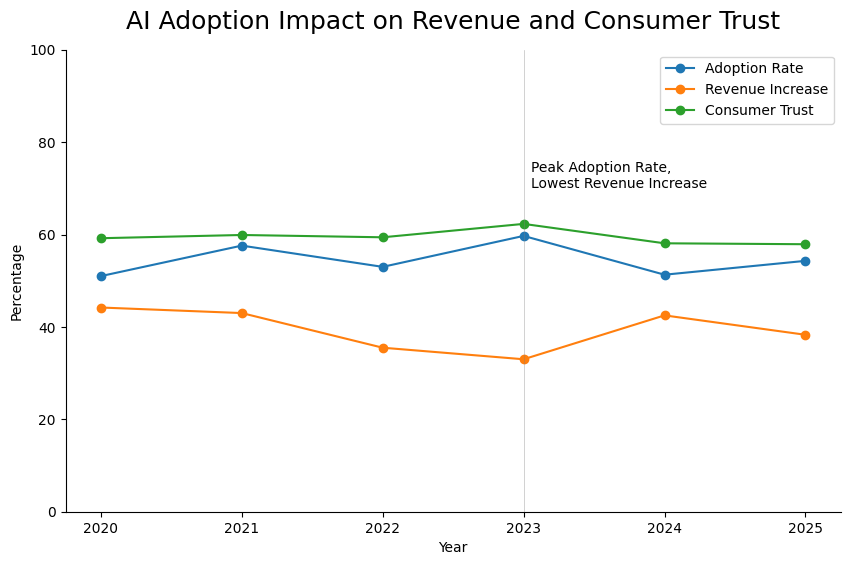

In [ ]:
#create the line plot
plt.figure(figsize=(10,6))
plt.plot(
    yearly_avgs.index, 
    yearly_avgs.values,
    label= ('Adoption Rate', 'Revenue Increase', 'Consumer Trust'),
    marker='o'
    )

#customize the labels and title
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.title("AI Adoption Impact on Revenue and Consumer Trust", fontsize = 18, pad=15)

#remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#create the verticle line at year 2023
ax.axvline(
    2023,
    color='gray',
    linewidth = 0.5,
    alpha = 0.5)

#write the label
ax.text(
    2023+0.05, 
    70,
    'Peak Adoption Rate, \nLowest Revenue Increase')

#create a legend and adjust the range of the y axis
plt.legend()
plt.ylim(0, 100)

plt.show()

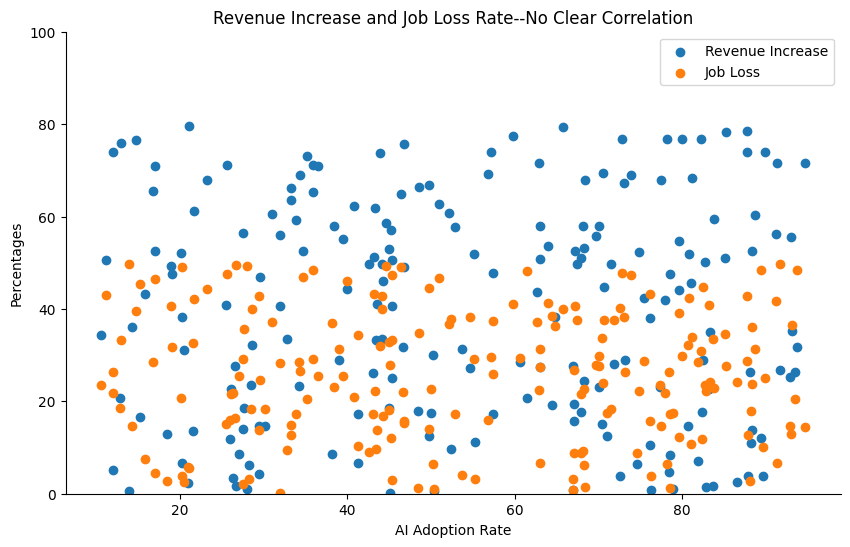

In [ ]:
plt.figure(figsize=(10,6))

#create the two scatter plots to put into one visualization
plt.scatter(
    content_df['ai_adoption_rate_(%)'], 
    content_df['revenue_increase_due_to_ai_(%)'],
    label = 'Revenue Increase') 
plt.scatter(
    content_df['ai_adoption_rate_(%)'], 
    content_df['job_loss_due_to_ai_(%)'],
    label = 'Job Loss')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('AI Adoption Rate')
plt.ylabel('Percentages')
plt.title('Revenue Increase and Job Loss Rate--No Clear Correlation')

plt.legend()
plt.ylim(0, 100)

plt.show()

In [ ]:
#grab each use case from the students table and each matching ai tool from the ai tools table
query5 = ''' 
    SELECT
        s.main_usage_case, ai.ai_tool
    FROM students s
    JOIN ai_tools ai on ai.ai_tool_id = s.ai_tool_id

'''
result5 = pd.read_sql(query5, conn)
result5

,main_usage_case,ai_tool
0,Code Debugging,Gemini Pro
1,Essay Drafting,GitHub Copilot
2,Literature Review,Perplexity
3,Essay Drafting,Claude
4,Code Debugging,ChatGPT
...,...,...
1495,Brainstorming,GitHub Copilot
1496,Essay Drafting,GitHub Copilot
1497,Code Debugging,GitHub Copilot
1498,Brainstorming,Perplexity


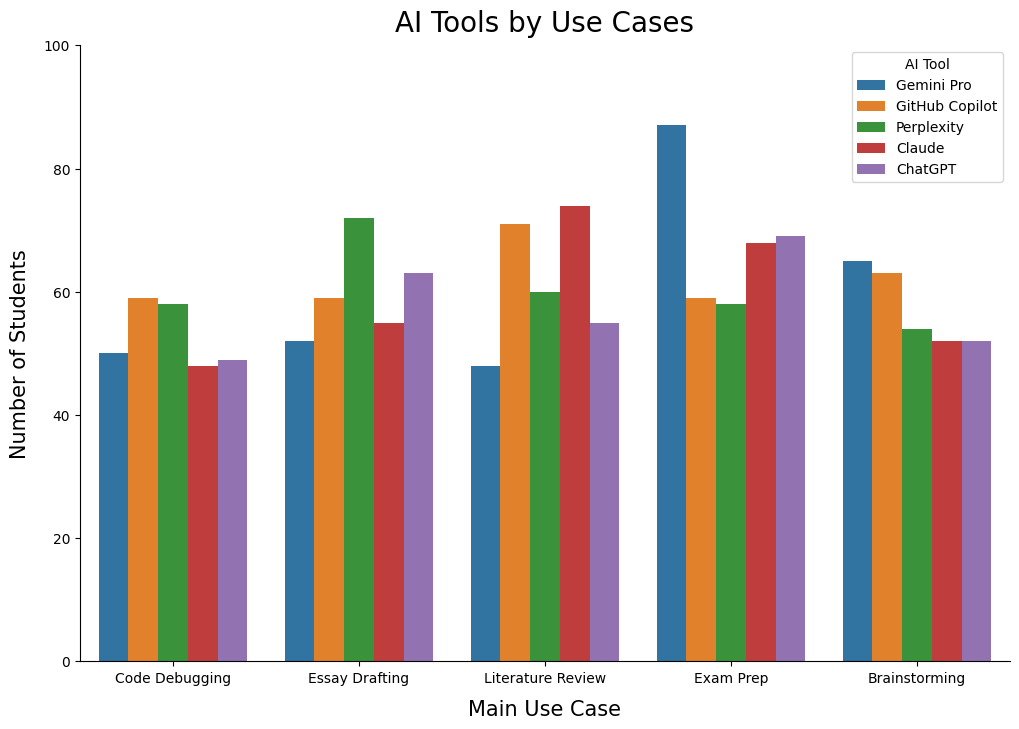

In [ ]:
plt.figure(figsize=(12,8))

#create the count chart
sns.countplot(data = result5, x = 'main_usage_case', hue = 'ai_tool')


plt.xlabel("Main Use Case", fontsize = 15, labelpad=10)
plt.ylabel("Number of Students", fontsize = 15, labelpad=10)
plt.title("AI Tools by Use Cases", fontsize=20, pad=10)

plt.legend(
    title = "AI Tool"
)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylim(0, 100)

plt.show()

In [ ]:
#create the gpa effects variables and grab the counts, then sort by usage case 
query6 = ''' 
    SELECT
        main_usage_case,
        SUM(gpa_baseline > gpa_post_ai) AS gpa_decline,
        SUM(gpa_baseline < gpa_post_ai) AS gpa_growth,
        SUM(gpa_baseline = gpa_post_ai) AS gpa_same
    FROM students
    GROUP BY main_usage_case
'''
result6 = pd.read_sql(query6, conn)
result6

,main_usage_case,gpa_decline,gpa_growth,gpa_same
0,Brainstorming,60,172,54
1,Code Debugging,44,165,55
2,Essay Drafting,50,181,70
3,Exam Prep,83,197,61
4,Literature Review,64,179,65


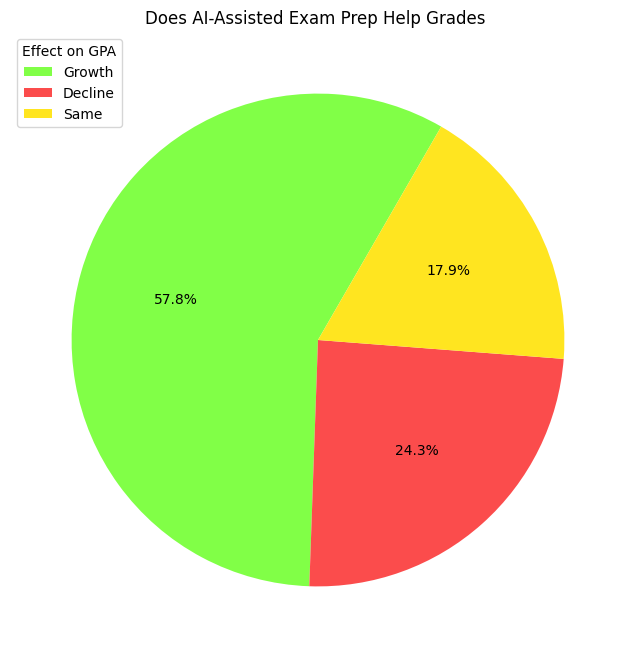

In [ ]:
#take the value specified (in this case, "Exam Prep")
exam_prep_gpa = result6[result6['main_usage_case'] == 'Exam Prep'].iloc[0]

#grab the gpa effects and make their labels
values = [
    exam_prep_gpa['gpa_growth'], 
    exam_prep_gpa['gpa_decline'], 
    exam_prep_gpa['gpa_same']
    ]
labels = [
    'Growth', 
    'Decline', 
    'Same']

#create the pie chart
plt.figure(figsize=(8,8))
plt.pie(
    values,
    autopct='%1.1f%%',
    startangle=60,
    colors=["#81ff47", "#fb4c4c", "#ffe520"]
)

plt.legend(
    labels = labels,
    loc = 'upper left',
    title = 'Effect on GPA')

plt.title('Does AI-Assisted Exam Prep Help Grades ')
plt.show()

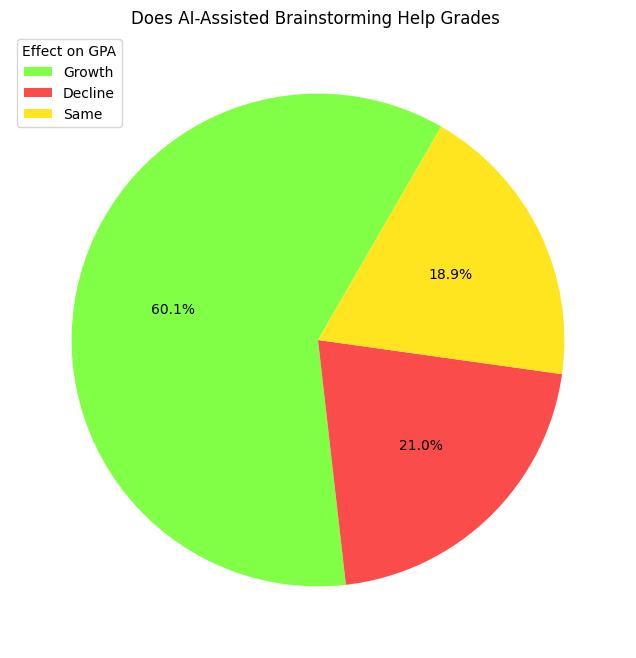

In [924]:
brainstorming_gpa = result6[result6['main_usage_case'] == 'Brainstorming'].iloc[0]

values = [
    brainstorming_gpa['gpa_growth'], 
    brainstorming_gpa['gpa_decline'], 
    brainstorming_gpa['gpa_same']
    ]
labels = [
    'Growth', 
    'Decline', 
    'Same']

plt.figure(figsize=(8,8))
plt.pie(
    values,
    autopct='%1.1f%%',
    startangle=60,
    colors=["#81ff47", "#fb4c4c", "#ffe520"]
)

plt.legend(
    labels = labels,
    loc = 'upper left',
    title = 'Effect on GPA'
)

plt.title('Does AI-Assisted Brainstorming Help Grades ')
plt.show()

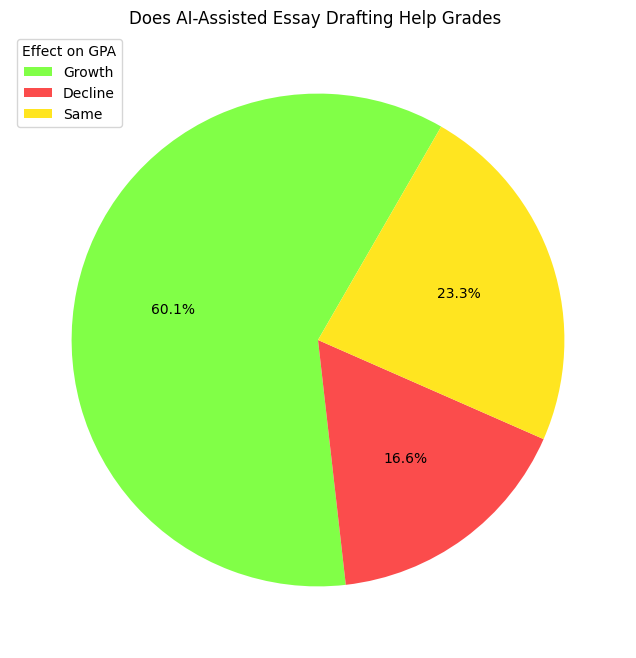

In [927]:
essay_gpa = result6[result6['main_usage_case'] == 'Essay Drafting'].iloc[0]

values = [
    essay_gpa['gpa_growth'], 
    essay_gpa['gpa_decline'], 
    essay_gpa['gpa_same']
    ]
labels = [
    'Growth', 
    'Decline', 
    'Same']

plt.figure(figsize=(8,8))
plt.pie(
    values,
    autopct='%1.1f%%',
    startangle=60,
    colors=["#81ff47", "#fb4c4c", "#ffe520"]
)

plt.legend(
    labels = labels,
    loc = 'upper left',
    title = 'Effect on GPA'
)

plt.title('Does AI-Assisted Essay Drafting Help Grades ')
plt.show()